# Phase 5 — Cost-Sensitive Evaluation and SHAP Interpretability

Phases 1–4 established *which* model ranks fraud best and whether it holds up
over time. Neither question is the one a bank actually asks, which is:

* **At what threshold should this run, and what does that cost in euros?**
* **Why was this particular transaction flagged?**

This notebook answers both, reading results only — nothing is refit here.

## Why this phase follows from Phase 3

Phase 3 found that the four imbalance strategies moved the *operating point*
along an essentially unchanged precision–recall curve, rather than improving
ranking quality. If the operating point is what resampling was really
changing, then it should be chosen deliberately and for a reason — which is
what a cost model provides.

## The methodological trap, and how it is avoided

The obvious approach is to sweep thresholds on the test set and report the
cheapest. That number is an **oracle**: it used the test labels to choose the
threshold, so it cannot be achieved in deployment and it flatters the model.
It is the same species of optimism this dissertation criticises elsewhere.

The headline numbers here therefore come from a threshold chosen on
**training out-of-fold scores only**, then frozen before the test set is
touched. The oracle is still computed, but reported strictly as an upper
bound so the optimism is visible rather than hidden.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from fraud import config  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R = config.RESULTS_DIR
sel = pd.read_csv(R / "threshold_selection.csv")
curves = pd.read_csv(R / "cost_curves.csv")
shap_imp = pd.read_csv(R / "shap_global_importance.csv")
shap_cond = pd.read_csv(R / "shap_class_conditional.csv")

MODEL_LABEL = {"xgboost": "XGBoost", "random_forest": "Random Forest",
               "logistic_regression": "Logistic Regression", "dnn": "DNN (focal loss)"}
MODEL_COLOR = {"xgboost": "#4C72B0", "random_forest": "#55A868",
               "logistic_regression": "#C44E52", "dnn": "#DD8452"}
RC = 10.0   # headline review cost, EUR

print(f"{len(sel)} threshold-selection rows, {len(curves):,} cost-curve points")

32 threshold-selection rows, 3,168 cost-curve points


## 2. The cost model

Every flagged transaction — right or wrong — costs a fixed human review.
Every missed fraud costs that transaction's own `Amount`, the money actually
lost. Catching a fraud saves its amount but still pays for one review.

    total_cost = review_cost × (TP + FP) + Σ Amount of FN

Two no-model baselines bracket any sensible system: flag nothing (lose every
fraud) or flag everything (review every transaction). Savings below are
always measured against the **better** of the two, which is deliberately
harsh — beating the worse one is trivial.

In [2]:
base = sel[(sel.review_cost == RC)].groupby("protocol").baseline_best.first()
for proto, b in base.items():
    n_fraud = int(sel[(sel.protocol == proto) & (sel.review_cost == RC)].iloc[0]
                  [["tp", "fn"]].sum())
    print(f"{proto:<15} do-nothing baseline EUR {b:>9,.0f}   ({n_fraud} frauds in test)")

chronological   do-nothing baseline EUR     7,728   (74 frauds in test)
stratified      do-nothing baseline EUR    14,766   (95 frauds in test)


## 3. Headline: deployed cost at a EUR 10 review cost

In [3]:
for proto in ("stratified", "chronological"):
    s = sel[(sel.protocol == proto) & (sel.review_cost == RC)].sort_values("cost_deployed")
    print(f"\n{proto.upper()}   baseline EUR {s.iloc[0].baseline_best:,.0f}")
    print(f"  {'model':<20}{'t*':>6}{'deployed':>11}{'default 0.5':>13}"
          f"{'oracle':>10}{'optimism':>10}{'saved':>10}")
    print("  " + "-" * 78)
    for _, r in s.iterrows():
        print(f"  {MODEL_LABEL[r.model]:<20}{r.threshold_selected_on_train:>6.2f}"
              f"{r.cost_deployed:>11,.0f}{r.cost_at_default_0_5:>13,.0f}"
              f"{r.cost_oracle_test:>10,.0f}{r.optimism_gap:>10,.0f}"
              f"{r.savings_vs_baseline:>10,.0f}")


STRATIFIED   baseline EUR 14,766
  model                   t*   deployed  default 0.5    oracle  optimism     saved
  ------------------------------------------------------------------------------
  XGBoost               0.26      4,592        4,782     4,562        30    10,175
  DNN (focal loss)      0.09      4,605        5,874     4,605         0    10,161
  Random Forest         0.22      4,633        5,023     4,582        51    10,134
  Logistic Regression   0.03      4,990       10,986     4,912        79     9,776

CHRONOLOGICAL   baseline EUR 7,728
  model                   t*   deployed  default 0.5    oracle  optimism     saved
  ------------------------------------------------------------------------------
  Random Forest         0.22      3,112        4,729     3,082        30     4,616
  XGBoost               0.11      3,337        4,211     3,235       102     4,390
  DNN (focal loss)      0.17      3,526        4,548     3,201       325     4,201
  Logistic Regression

### Threshold choice matters more than model choice — with a caveat

Properly thresholded, the four models land within a few per cent of each
other. At the default 0.5 they spread out by more than a factor of two. A
well-thresholded logistic regression is competitive with a badly-thresholded
XGBoost, which is not a conclusion PR-AUC alone would suggest.

Section 4a tests whether these euro gaps survive sampling noise. Several of
them do not, and the pattern of which ones do is the more interesting
result.

In [4]:
s = sel[(sel.protocol == "stratified") & (sel.review_cost == RC)]
spread_dep = s.cost_deployed.max() / s.cost_deployed.min()
spread_def = s.cost_at_default_0_5.max() / s.cost_at_default_0_5.min()
print(f"stratified, review cost EUR {RC:.0f}")
print(f"  spread across models when each is properly thresholded : {spread_dep:.2f}x")
print(f"  spread across models at the default 0.5                : {spread_def:.2f}x")
print(f"\n  mean optimism gap (deployed - oracle): "
      f"EUR {sel[sel.review_cost == RC].optimism_gap.mean():,.0f}")
print("  -> small, so thresholds selected on training data transfer to the test set")

stratified, review cost EUR 10
  spread across models when each is properly thresholded : 1.09x
  spread across models at the default 0.5                : 2.30x

  mean optimism gap (deployed - oracle): EUR 88
  -> small, so thresholds selected on training data transfer to the test set


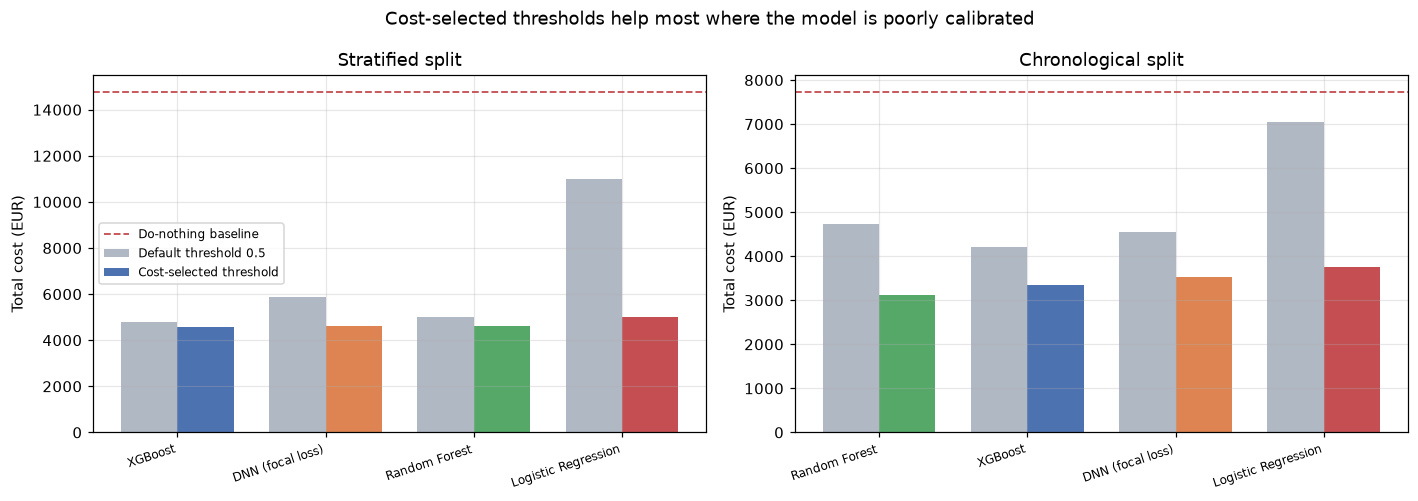

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=False)
for ax, proto in zip(axes, ("stratified", "chronological")):
    s = sel[(sel.protocol == proto) & (sel.review_cost == RC)].sort_values("cost_deployed")
    x = np.arange(len(s)); w = 0.38
    ax.bar(x - w/2, s.cost_at_default_0_5, w, label="Default threshold 0.5",
           color="#B0B8C4")
    ax.bar(x + w/2, s.cost_deployed, w, label="Cost-selected threshold",
           color=[MODEL_COLOR[m] for m in s.model])
    ax.axhline(s.iloc[0].baseline_best, color="#C44E52", linestyle="--",
               linewidth=1.2, label="Do-nothing baseline")
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABEL[m] for m in s.model], rotation=18,
                       ha="right", fontsize=8)
    ax.set_title(f"{proto.capitalize()} split")
    ax.set_ylabel("Total cost (EUR)")
axes[0].legend(fontsize=8)
fig.suptitle("Cost-selected thresholds help most where the model is poorly calibrated",
             fontsize=12)
fig.tight_layout()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES_DIR / "phase5_cost_by_model.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 4a. Do the euro gaps survive sampling noise?

The cost figures rest on 95 frauds (74 chronological), and total cost is
dominated by a handful of large-amount transactions. A difference of a few
hundred euros can look decisive while sitting well inside sampling noise, so
the central claim — that a cost-selected threshold beats the default 0.5 —
needs a confidence interval rather than a point estimate.

Bootstrapping the test set gives a clear and more useful answer than the
unqualified claim: **the gain is significant for badly-calibrated models and
not for well-calibrated ones**.

  protocol       model                   gain                95% CI  verdict
  ----------------------------------------------------------------------
  stratified     XGBoost                  190  [    -60,    +670]  not significant
  stratified     Random Forest            391  [   -120,  +1,109]  not significant
  stratified     Logistic Regression    5,996  [ +1,774, +11,887]  SIGNIFICANT
  stratified     DNN (focal loss)       1,269  [   +495,  +2,196]  SIGNIFICANT
  chronological  XGBoost                  874  [   -152,  +2,895]  not significant
  chronological  Random Forest          1,618  [   +102,  +4,011]  SIGNIFICANT
  chronological  Logistic Regression    3,289  [   +456,  +7,222]  SIGNIFICANT
  chronological  DNN (focal loss)       1,022  [    -25,  +3,022]  not significant

  significant in 4 of 8 cells


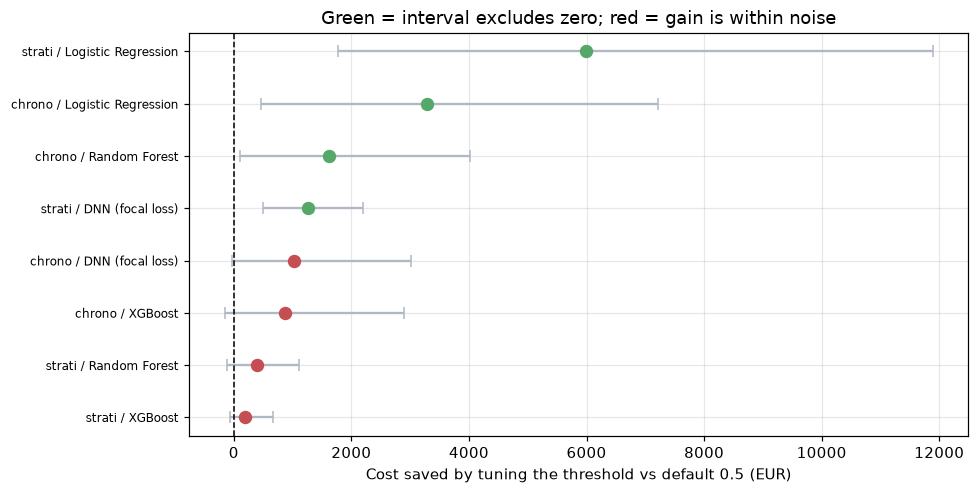

In [6]:
boot = pd.read_csv(R / "threshold_gain_bootstrap.csv")
print(f"  {'protocol':<15}{'model':<20}{'gain':>8}{'95% CI':>22}  verdict")
print("  " + "-" * 70)
for _, r in boot.iterrows():
    print(f"  {r.protocol:<15}{MODEL_LABEL[r.model]:<20}{r.gain:>8,.0f}"
          f"  [{r.ci_lo:>+7,.0f},{r.ci_hi:>+8,.0f}]  "
          f"{'SIGNIFICANT' if r.significant else 'not significant'}")
print(f"\n  significant in {int(boot.significant.sum())} of {len(boot)} cells")

fig, ax = plt.subplots(figsize=(9, 4.6))
b = boot.sort_values("gain")
ylab = [f"{r.protocol[:6]} / {MODEL_LABEL[r.model]}" for _, r in b.iterrows()]
y = np.arange(len(b))
ax.errorbar(b.gain, y, xerr=[b.gain - b.ci_lo, b.ci_hi - b.gain], fmt="o",
            capsize=4, color="#4C72B0", ecolor="#B0B8C4")
for i, (_, r) in enumerate(b.iterrows()):
    ax.scatter([r.gain], [i], s=60, zorder=5,
               color="#55A868" if r.significant else "#C44E52")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(ylab, fontsize=8)
ax.set_xlabel("Cost saved by tuning the threshold vs default 0.5 (EUR)")
ax.set_title("Green = interval excludes zero; red = gain is within noise")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase5_threshold_gain_ci.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 4. The cost curve is a plateau, not a spike

This tempers the section above. The optimum is not a knife edge: a wide band
of thresholds performs within a few per cent of the best. What the default
0.5 gets wrong is not imprecision but *being outside the band altogether* —
with 0.17% positives, a 0.5 probability cut-off is far too conservative.

The practical instruction is therefore "do not use 0.5", not "find the exact
optimum".

In [7]:
c = curves[(curves.model == "xgboost") & (curves.protocol == "chronological")
           & (curves.review_cost == RC)]
best = c.total_cost.min()
band = c[c.total_cost <= best * 1.05]
print(f"chronological XGBoost, review cost EUR {RC:.0f}")
print(f"  minimum cost EUR {best:,.0f} at threshold "
      f"{c.loc[c.total_cost.idxmin()].threshold:.2f}")
print(f"  within 5% of minimum: thresholds {band.threshold.min():.2f}"
      f"-{band.threshold.max():.2f}  ({len(band)} of {len(c)} grid points)")
at_default = c[np.isclose(c.threshold, 0.50)].iloc[0].total_cost
print(f"  cost at default 0.5: EUR {at_default:,.0f} "
      f"({100 * (at_default - best) / best:.0f}% above the minimum)")

chronological XGBoost, review cost EUR 10
  minimum cost EUR 3,235 at threshold 0.42
  within 5% of minimum: thresholds 0.03-0.46  (41 of 99 grid points)
  cost at default 0.5: EUR 4,211 (30% above the minimum)


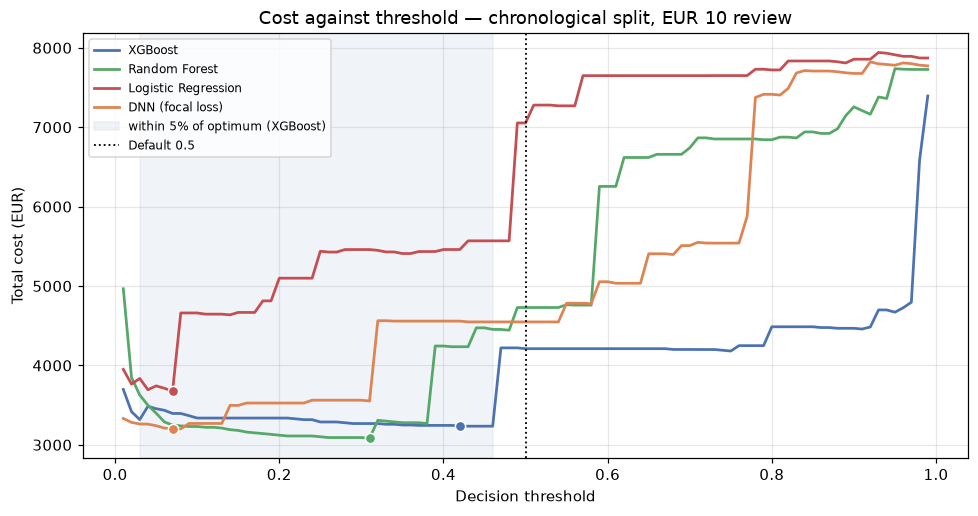

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for model in ("xgboost", "random_forest", "logistic_regression", "dnn"):
    c = curves[(curves.model == model) & (curves.protocol == "chronological")
               & (curves.review_cost == RC)]
    if c.empty:
        continue
    ax.plot(c.threshold, c.total_cost, linewidth=1.8,
            color=MODEL_COLOR[model], label=MODEL_LABEL[model])
    lo = c.loc[c.total_cost.idxmin()]
    ax.scatter([lo.threshold], [lo.total_cost], color=MODEL_COLOR[model],
               s=45, zorder=5, edgecolor="white")

c = curves[(curves.model == "xgboost") & (curves.protocol == "chronological")
           & (curves.review_cost == RC)]
band = c[c.total_cost <= c.total_cost.min() * 1.05]
ax.axvspan(band.threshold.min(), band.threshold.max(), color="#4C72B0",
           alpha=0.08, label="within 5% of optimum (XGBoost)")
ax.axvline(0.5, color="black", linestyle=":", linewidth=1.2,
           label="Default 0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Total cost (EUR)")
ax.set_title("Cost against threshold — chronological split, EUR 10 review")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase5_cost_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()

### The threshold responds to the review cost, as economics predicts

The review cost is a business parameter, not a property of the data, so
every result is reported across a range. When reviews are cheap it pays to
flag generously; when they are expensive the model should become choosier.
That the selected threshold moves in that direction is a sanity check on the
cost model itself.

  protocol        review EUR     t*  flagged  caught  missed   cost EUR
  ----------------------------------------------------------------------
  chronological            2   0.11       66      56      18      2,809
  chronological            5   0.11       66      56      18      3,007
  chronological           10   0.11       66      56      18      3,337
  chronological           25   0.12       66      56      18      4,327
  stratified               2   0.01      180      81      14      3,682
  stratified               5   0.08       88      74      21      4,249
  stratified              10   0.26       78      72      23      4,592
  stratified              25   0.26       78      72      23      5,762


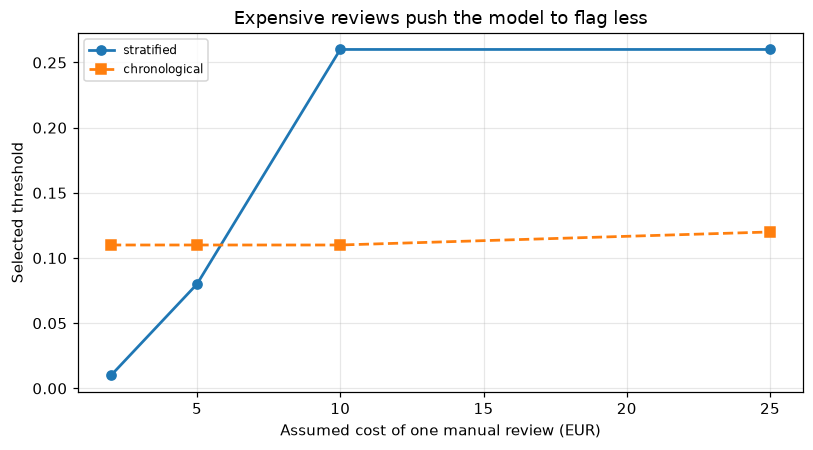

In [9]:
x = sel[sel.model == "xgboost"].sort_values(["protocol", "review_cost"])
print(f"  {'protocol':<15}{'review EUR':>11}{'t*':>7}{'flagged':>9}{'caught':>8}"
      f"{'missed':>8}{'cost EUR':>11}")
print("  " + "-" * 70)
for _, r in x.iterrows():
    print(f"  {r.protocol:<15}{r.review_cost:>11.0f}"
          f"{r.threshold_selected_on_train:>7.2f}{int(r.tp + r.fp):>9}"
          f"{int(r.tp):>8}{int(r.fn):>8}{r.cost_deployed:>11,.0f}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for proto, style in (("stratified", "-o"), ("chronological", "--s")):
    d = x[x.protocol == proto]
    ax.plot(d.review_cost, d.threshold_selected_on_train, style,
            linewidth=1.8, label=proto)
ax.set_xlabel("Assumed cost of one manual review (EUR)")
ax.set_ylabel("Selected threshold")
ax.set_title("Expensive reviews push the model to flag less")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase5_threshold_sensitivity.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 5. SHAP — why a transaction is flagged

Cost analysis fixes *where* the model draws its line. It says nothing about
*why* an individual transaction ends up on one side of it, which is what an
investigator needs and what a regulator would ask for.

TreeExplainer is exact for tree ensembles, so these attributions carry no
sampling error.

### An honest ceiling

`V1`–`V28` are anonymised PCA components published to protect commercial
confidentiality. SHAP can rank them and give the direction and size of their
effect, but nobody — not this project, not the dataset's authors — can say
what `V14` corresponds to in the real world. Only `Time` and `Amount` are
interpretable in plain language.

So this project delivers **mathematical** transparency (which inputs moved
this decision, and by how much) but not **semantic** transparency (what those
inputs mean). That is a property of the dataset rather than a limitation of
the method: the same code on un-anonymised features would deliver both.

In [10]:
proto = "chronological"
imp = shap_imp[shap_imp.protocol == proto].head(12)
cond = shap_cond[shap_cond.protocol == proto].set_index("feature")

print(f"Top features by mean |SHAP| — {proto}\n")
print(f"  {'rank':>4}  {'feature':<8}{'mean|SHAP|':>11}{'share':>8}"
      f"{'on frauds':>11}{'on legit':>10}")
print("  " + "-" * 54)
for _, r in imp.iterrows():
    c = cond.loc[r.feature]
    print(f"  {int(r['rank']):>4}  {r.feature:<8}{r.mean_abs_shap:>11.4f}"
          f"{r.share_pct:>7.1f}%{c.mean_shap_fraud:>11.3f}{c.mean_shap_legit:>10.3f}")

Top features by mean |SHAP| — chronological

  rank  feature  mean|SHAP|   share  on frauds  on legit
  ------------------------------------------------------
     1  V4           1.3040   17.8%      0.885    -1.158
     2  V12          0.8601   11.8%      0.704    -0.859
     3  V14          0.8534   11.7%      3.165    -0.622
     4  V10          0.6375    8.7%      1.250    -0.592
     5  V8           0.3367    4.6%     -0.152    -0.001
     6  Time         0.2902    4.0%     -0.293    -0.290
     7  Amount       0.2538    3.5%     -0.003    -0.134
     8  V11          0.2491    3.4%      0.094    -0.240
     9  V19          0.1883    2.6%      0.027    -0.125
    10  V16          0.1789    2.4%      0.327    -0.091
    11  V7           0.1746    2.4%      0.192    -0.146
    12  V1           0.1602    2.2%     -0.028    -0.087


Note the two right-hand columns. Averaged over *all* rows, almost every
feature appears to push toward "legitimate" — an artefact of 99.8% of rows
being legitimate, not a statement about the feature. Splitting by true class
shows the real behaviour: `V14` contributes over +3 log-odds on genuine
frauds while pushing the other way on legitimate ones.

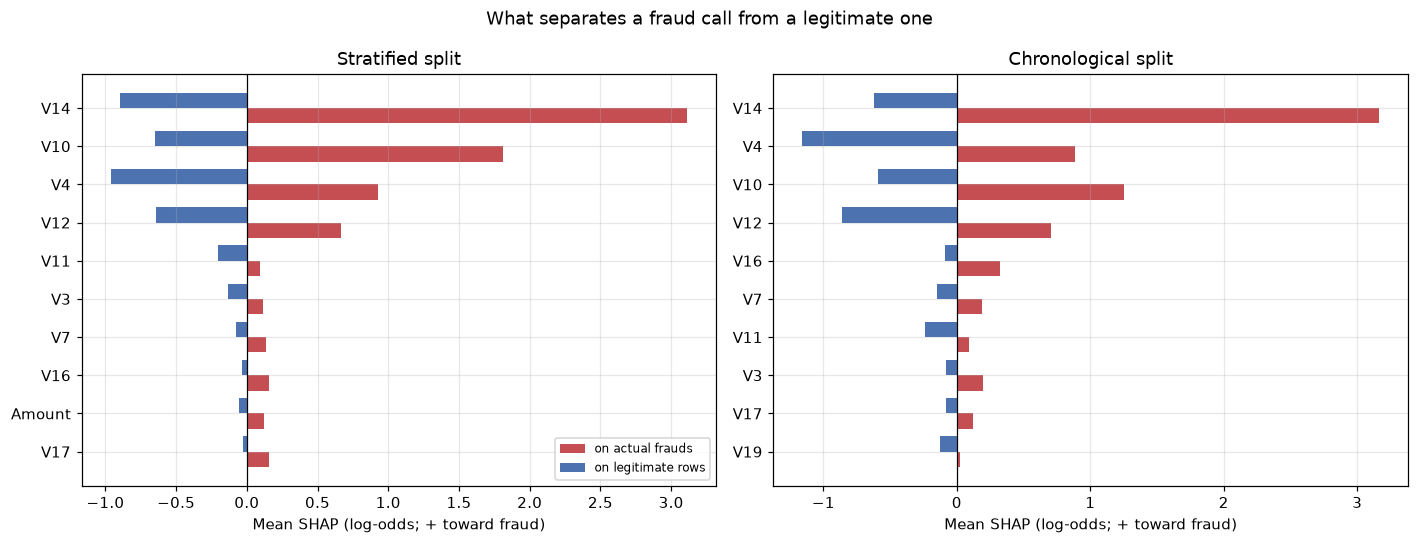

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, proto in zip(axes, ("stratified", "chronological")):
    d = shap_cond[shap_cond.protocol == proto].head(10).iloc[::-1]
    y = np.arange(len(d))
    ax.barh(y - 0.2, d.mean_shap_fraud, 0.4, color="#C44E52",
            label="on actual frauds")
    ax.barh(y + 0.2, d.mean_shap_legit, 0.4, color="#4C72B0",
            label="on legitimate rows")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(d.feature)
    ax.set_xlabel("Mean SHAP (log-odds; + toward fraud)")
    ax.set_title(f"{proto.capitalize()} split")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("What separates a fraud call from a legitimate one", fontsize=12)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase5_shap_separation.png", dpi=150,
            bbox_inches="tight")
plt.show()

### Time behaves differently under the two protocols

`Time` is the one place where the split protocol visibly changes what the
model leans on. Under the random split, training and test timestamps are
interleaved and `Time` ranks 16th with a mean SHAP near zero. Under the
chronological split every test timestamp lies beyond the training range, so
all test rows fall into the model's terminal `Time` bin and receive a
systematic push toward "legitimate".

The effect is real and measurable, but its practical consequence turned out
to be small — dropping `Time` entirely changes chronological PR-AUC by
+0.004, well inside the fold-to-fold spread. Because the offset is close to
constant it shifts scores without much changing their *order*, and PR-AUC is
a ranking metric. It is worth reporting as a modelling artefact to be aware
of, not as a defect that invalidates the results.

In [12]:
t = shap_imp[shap_imp.feature.isin(["Time", "Amount"])]
for _, r in t.iterrows():
    c = shap_cond[(shap_cond.protocol == r.protocol)
                  & (shap_cond.feature == r.feature)].iloc[0]
    print(f"  {r.protocol:<15}{r.feature:<8} rank {int(r['rank']):>2}"
          f"  share {r.share_pct:>4.1f}%   mean SHAP {r.mean_shap:>+7.4f}")

  stratified     Amount   rank 11  share  2.1%   mean SHAP -0.0584
  stratified     Time     rank 16  share  1.8%   mean SHAP +0.0069
  chronological  Time     rank  6  share  4.0%   mean SHAP -0.2902
  chronological  Amount   rank  7  share  3.5%   mean SHAP -0.1335


## 6. Three transactions, explained

Selected at the **deployed** threshold rather than 0.5, so these describe the
model as it would actually run.

In [13]:
for case, title in [
    ("caught_fraud", "Caught fraud — highest-value correct flag"),
    ("missed_fraud", "Missed fraud — the most expensive mistake"),
    ("false_alarm",  "False alarm — most confident wrong flag"),
]:
    path = R / f"shap_case_{case}_chronological.csv"
    if not path.exists():
        continue
    d = pd.read_csv(path)
    print(f"\n{title}")
    print(f"  {'feature':<9}{'value':>12}{'SHAP':>9}   effect")
    print("  " + "-" * 46)
    for _, r in d.head(5).iterrows():
        print(f"  {r.feature:<9}{r.value:>12,.2f}{r.shap:>+9.3f}   {r.pushes}")


Caught fraud — highest-value correct flag
  feature         value     SHAP   effect
  ----------------------------------------------
  V14             -6.11   +4.205   toward fraud
  V10             -4.44   +1.712   toward fraud
  V12             -3.81   +1.224   toward fraud
  V4               3.25   +1.192   toward fraud
  Amount       1,504.93   +0.592   toward fraud

Missed fraud — the most expensive mistake
  feature         value     SHAP   effect
  ----------------------------------------------
  V12              0.98   -1.157   toward legit
  V14              0.98   -1.025   toward legit
  V4               0.16   -0.732   toward legit
  V26             -1.13   +0.473   toward fraud
  Amount       1,096.99   +0.466   toward fraud

False alarm — most confident wrong flag
  feature         value     SHAP   effect
  ----------------------------------------------
  V14             -3.79   +4.316   toward fraud
  V10             -2.57   +2.021   toward fraud
  V4               2.01 

The three cases say different things.

The **caught fraud** is the reassuring case: several strong components line
up and the model is confident for legible reasons.

The **missed fraud** is the important one. It is the same transaction under
both protocols, it scores 0.000, and its `V14`, `V12` and `V4` all sit at
unremarkable values. The model does not narrowly miss it — it sees nothing
wrong at all. No threshold change and no retraining schedule would catch
this, because in this feature space it does not look like fraud. That is a
limit of the data, and it belongs in the write-up as one.

The **false alarm** exposes a gap in the cost model rather than in the
classifier. Under the chronological protocol the most confident false
positive is a EUR 2.00 transaction — the EUR 10 review costs five times the
amount at risk. A production system would skip review below some amount
floor; the cost model as written has no such floor, and adding one is a
concrete improvement this analysis surfaced.

## Findings

**1. Threshold tuning helps where the model is badly calibrated, and not
otherwise.** Bootstrapping the euro gaps shows the improvement over the
default 0.5 is significant in only four of eight model/protocol cells — and
XGBoost, the strongest model, is in neither of its two. For logistic
regression the gain is large and unambiguous (EUR 5,996, CI +1,774 to
+11,887); for XGBoost it is EUR 190 with an interval spanning zero. A 0.5
cut-off is badly wrong for a model whose probabilities are poorly calibrated
under 0.17% prevalence, and roughly right for one whose are not.

**2. The practical effect is that tuning compresses the differences between
models.** Properly thresholded the four sit within a few per cent of each
other; at 0.5 they span more than a factor of two. Tuning mostly rescues the
weaker models up to the level the best model already reached — which is a
more precise statement than "threshold choice beats model choice", and the
one the intervals support.

**2b. The optimum is a plateau, not a point.** Roughly 40% of the threshold
grid lands within 5% of the minimum cost. Where the default 0.5 fails, it
fails by sitting outside that band entirely, not by being imprecise within
it.

**3. Thresholds chosen on training data transfer.** The gap between the
deployed threshold and the test-set oracle is small, which is what licenses
reporting the deployed figure as the headline.

**4. Every model beats doing nothing by a wide margin**, and the cost model
behaves sensibly: as reviews get more expensive the selected threshold rises
and the system flags fewer transactions.

**5. The model concentrates on a few components** — `V14`, `V10`, `V4`,
`V12` — which are the same ones the literature reports as most
discriminative for this dataset. Useful external validation that the
pipeline learned signal rather than an artefact of preprocessing.

**6. Some fraud is invisible in this feature space.** The most expensive
miss looks entirely ordinary on every feature the model uses.

### Limitations

Interpretability stops at the PCA boundary: attributions are exact, but the
features they attribute to have no public meaning.

The cost model is deliberately simple. Reviews cost a flat fee, missed fraud
costs face value, and there is no amount floor below which review is not
worth ordering — a gap the EUR 2.00 false alarm makes concrete. Reputational
cost, customer friction from false positives, and partial recovery of
fraudulent charges are all omitted.

Review costs are assumed, not observed. Results are reported across a range
for that reason, and no single figure in this notebook should be read as a
prediction of what a real deployment would save.